In [8]:
import pandas as pd
import matplotlib.pyplot as plt

theory = pd.read_csv('../data/joint_theory.csv')
simulation = pd.read_csv('../data/joint_simulation.csv')


In [9]:
stats = simulation.groupby(['topology', 'added_vertices', 'total_vertices']).agg(
    simulation_mean=('absorption_time', 'mean'),
    simulation_variance=('absorption_time', 'var'),
    simulation_prob_cheese=('absorbing_state', lambda s: (s == 0).mean())
).reset_index()

theory_renamed = theory.rename(columns={
    'mean_absorption_time': 'theory_mean',
    'variance': 'theory_variance',
    'prob_cheese': 'theory_prob_cheese',
    'prob_cat': 'theory_prob_cat'
})

results = theory_renamed.merge(stats, on=['topology', 'added_vertices', 'total_vertices'])
results.sort_values(by=['added_vertices', 'topology'])


,topology,added_vertices,total_vertices,initial_state,theory_mean,theory_variance,theory_prob_cheese,theory_prob_cat,simulation_mean,simulation_variance,simulation_prob_cheese
2,bypass_route,2,9,3,15.0,178.0,0.5,0.5,14.9839,176.692910,0.5012
0,dead_end,2,9,3,15.0,184.0,0.5,0.5,15.1880,189.698026,0.5064
1,petal_cycle,2,9,3,18.0,258.0,0.5,0.5,17.9641,262.065418,0.5012
5,bypass_route,3,10,3,17.0,256.0,0.5,0.5,16.6960,255.639548,0.4953
3,dead_end,3,10,3,18.0,339.0,0.5,0.5,18.0334,333.710656,0.4980
4,petal_cycle,3,10,3,21.0,392.0,0.5,0.5,21.1648,403.392380,0.4988
8,bypass_route,4,11,3,19.0,358.0,0.5,0.5,18.9091,352.322869,0.5017
6,dead_end,4,11,3,21.0,584.0,0.5,0.5,20.8170,560.101321,0.4998
7,petal_cycle,4,11,3,24.0,568.0,0.5,0.5,24.0396,553.791211,0.5027
11,bypass_route,5,12,3,21.0,488.0,0.5,0.5,21.2102,501.533569,0.4948


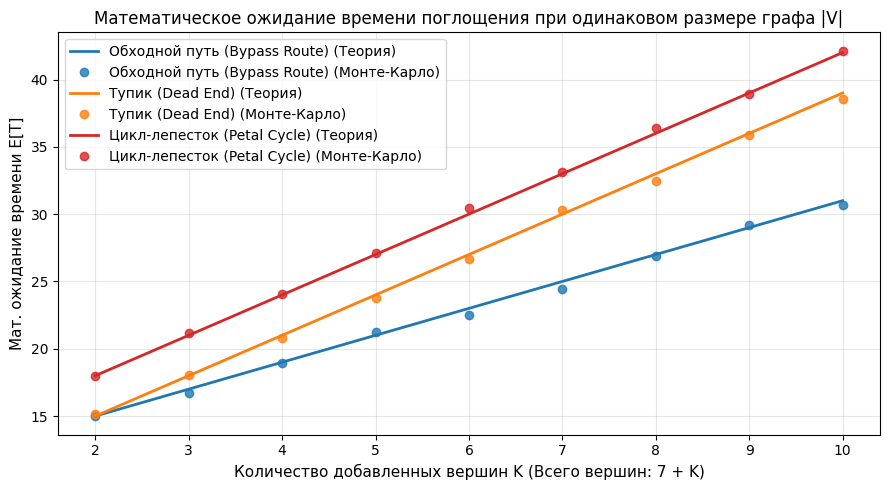

In [12]:
plt.figure(figsize=(9, 5))

topology_names = {
    'dead_end': 'Тупик (Dead End)',
    'petal_cycle': 'Цикл-лепесток (Petal Cycle)',
    'bypass_route': 'Обходной путь (Bypass Route)'
}
colors = {
    'dead_end': 'tab:orange',
    'petal_cycle': 'tab:red',
    'bypass_route': 'tab:blue'
}

for top in ['bypass_route', 'dead_end', 'petal_cycle']:
    sub = results[results['topology'] == top]
    plt.plot(sub['added_vertices'], sub['theory_mean'], '-', color=colors[top], linewidth=2, label=f"{topology_names[top]} (Теория)")
    plt.plot(sub['added_vertices'], sub['simulation_mean'], 'o', color=colors[top], markersize=6, alpha=0.8, label=f"{topology_names[top]} (Монте-Карло)")

plt.title('Математическое ожидание времени поглощения при одинаковом размере графа |V|', fontsize=12)
plt.xlabel('Количество добавленных вершин K (Всего вершин: 7 + K)', fontsize=11)
plt.ylabel('Мат. ожидание времени E[T]', fontsize=11)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    "../plots/joint_experiment_mean.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


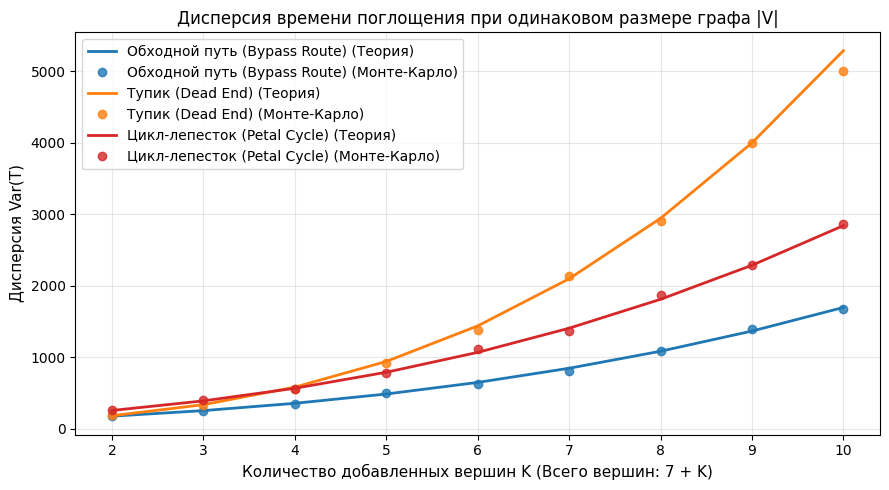

In [11]:
plt.figure(figsize=(9, 5))

for top in ['bypass_route', 'dead_end', 'petal_cycle']:
    sub = results[results['topology'] == top]
    plt.plot(sub['added_vertices'], sub['theory_variance'], '-', color=colors[top], linewidth=2, label=f"{topology_names[top]} (Теория)")
    plt.plot(sub['added_vertices'], sub['simulation_variance'], 'o', color=colors[top], markersize=6, alpha=0.8, label=f"{topology_names[top]} (Монте-Карло)")

plt.title('Дисперсия времени поглощения при одинаковом размере графа |V|', fontsize=12)
plt.xlabel('Количество добавленных вершин K (Всего вершин: 7 + K)', fontsize=11)
plt.ylabel('Дисперсия Var(T)', fontsize=11)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    "../plots/joint_experiment_variance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


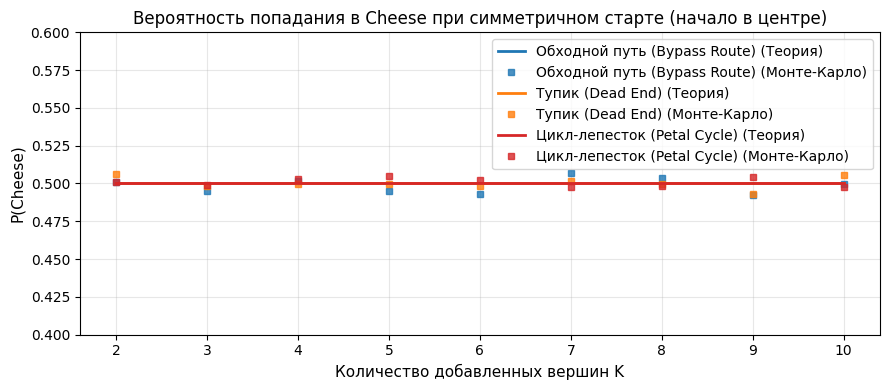

In [ ]:
plt.figure(figsize=(9, 4))

for top in ['bypass_route', 'dead_end', 'petal_cycle']:
    sub = results[results['topology'] == top]
    plt.plot(sub['added_vertices'], sub['theory_prob_cheese'], '-', color=colors[top], linewidth=2, label=f"{topology_names[top]} (Теория)")
    plt.plot(sub['added_vertices'], sub['simulation_prob_cheese'], 's', color=colors[top], markersize=5, alpha=0.8, label=f"{topology_names[top]} (Монте-Карло)")

plt.title('Вероятность попадания в Cheese при симметричном старте (начало в центре)', fontsize=12)
plt.xlabel('Количество добавленных вершин K', fontsize=11)
plt.ylabel('P(Cheese)', fontsize=11)
plt.ylim(0.4, 0.6)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
